In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
color = cv2.imread('/kaggle/input/datasets/abhashkharel7/imageippr/rgb.jpeg')

In [3]:
input = cv2.imread('/kaggle/input/datasets/abhashkharel7/imageippr/flower.jpg')
# gray_img = cv2.cvtColor(input, cv2.COLOR_BGR2GRAY)


# **RGB to Gray Conversion**

In [4]:
def rgb_to_grayscale(img):
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]
    gray = 0.2989 * R + 0.5870 * G + 0.1140 * B
    return gray.astype(np.uint8)

In [5]:
output = rgb_to_grayscale(color)

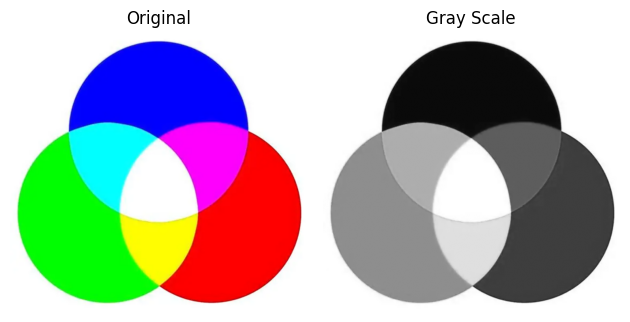

In [6]:
plt.subplot(1, 2, 1)
plt.imshow(color, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(output, cmap='gray')
plt.title('Gray Scale')
plt.axis('off')
plt.tight_layout()
plt.show()

# **Digital Negative**

In [7]:
def negImg(gray):
    neg=255-gray
    return neg

In [8]:
output = negImg(input)

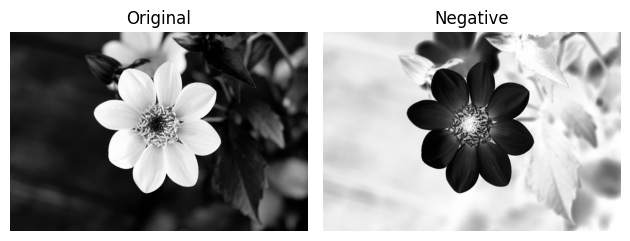

In [9]:
plt.subplot(1, 2, 1)
plt.imshow(input, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(output, cmap='gray')
plt.title('Negative')
plt.axis('off')
plt.tight_layout()
plt.show()

# **Thresholding**

In [10]:
img = cv2.imread('/kaggle/input/datasets/abhashkharel7/imageippr/flower.jpg')
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [11]:
def threshold(img, T):
    h, w = img.shape
    binary = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            if img[i, j] > T:
                binary[i, j] = 255
            else:
                binary[i, j] = 0
    return binary

In [12]:
output = threshold(gray_img,50)

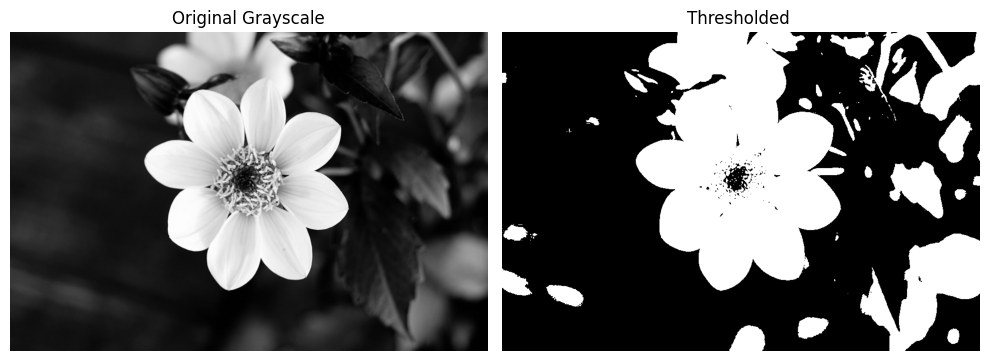

In [13]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray_img, cmap='gray')
plt.title("Original Grayscale")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(output, cmap='gray')
plt.title("Thresholded ")
plt.axis('off')
plt.tight_layout()
plt.show()

# **Intensity Silcing**

In [14]:
def intensity_slicing(img):
    rows, cols = img.shape
    result = np.zeros((rows, cols), dtype=np.uint8)
    for i in range(rows):
        for j in range(cols):
            pixel = img[i, j]
            if pixel <= 100:
                result[i, j] = 0
            elif (pixel>100 and pixel < 200):
                result[i, j] = pixel
            else:
                result[i, j] = 255
    return result

In [15]:
sliced_img = intensity_slicing(gray_img)

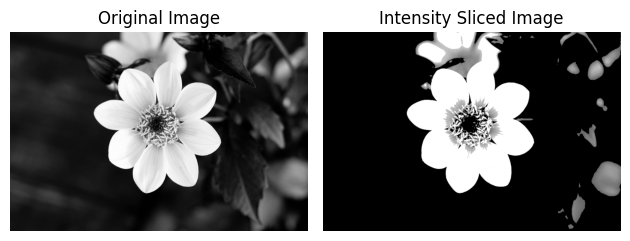

In [16]:
plt.subplot(1, 2, 1)
plt.imshow(gray_img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(sliced_img, cmap='gray')
plt.title('Intensity Sliced Image')
plt.axis('off')
plt.tight_layout()
plt.show()

# **Contrast Stretching**

In [17]:
a = cv2.imread('/kaggle/input/datasets/abhashkharel7/imageippr/LowContrastImage2.jpeg')

In [18]:
def contrast_stretch(img):
    r_min = np.min(img)
    r_max = np.max(img)
    stretched = (img - r_min) * 255.0 / (r_max - r_min)
    stretched = stretched.astype(np.uint8)
    return stretched


In [19]:
stretched_img = contrast_stretch(a)

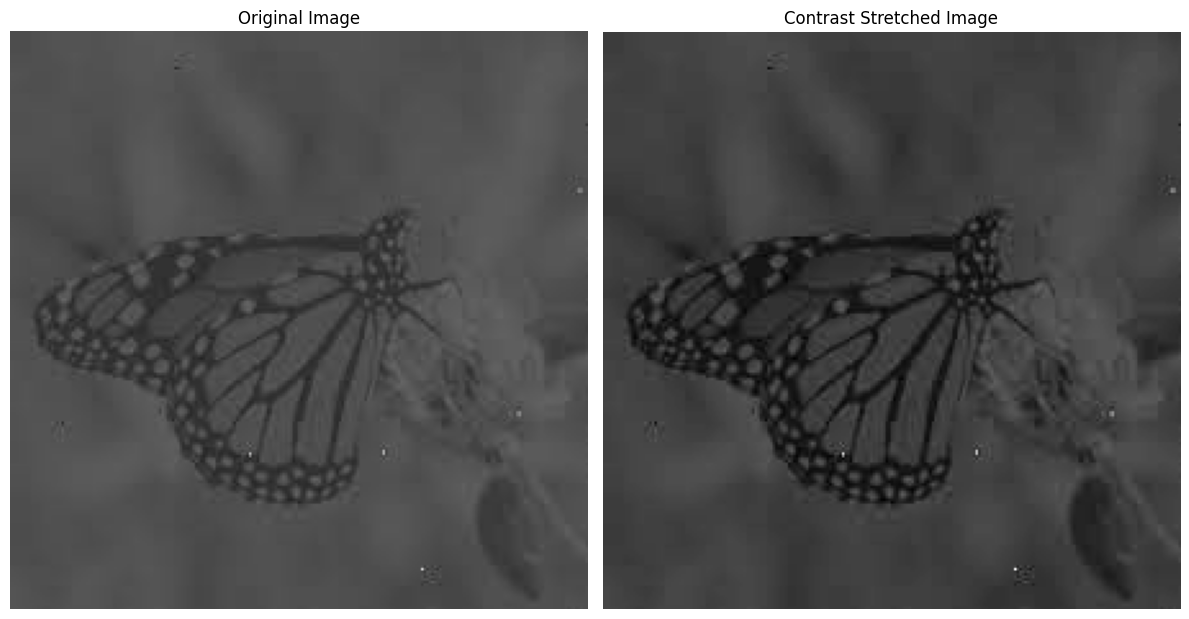

In [20]:

plt.figure(figsize=(12, 8))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(a, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(stretched_img, cmap='gray')
plt.title("Contrast Stretched Image")
plt.axis('off')
plt.tight_layout()
plt.show()

# **Log Transform**

In [21]:
def log_transform(img):
    img_float = img.astype(np.float32)
    c = 255 / np.log(1 + np.max(img_float))
    log_image = c * np.log(1 + img_float)
    log_image = np.uint8(np.clip(log_image, 0, 255))
    return log_image

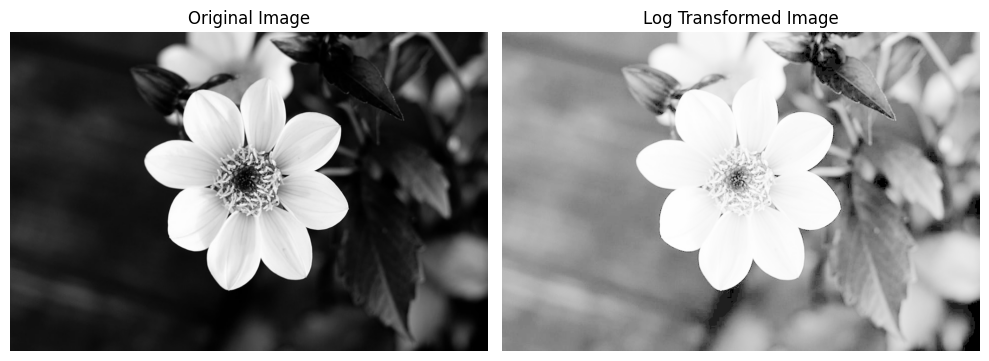

In [22]:
log_img = log_transform(input)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(input, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(log_img, cmap='gray')
plt.title('Log Transformed Image')
plt.axis('off')
plt.tight_layout()
plt.show()

# **Power Transform**

In [23]:
def gamma_transform(img, gamma):
    img_normalized = img / 255.0 # Normalize to [0,1]
    gamma_corrected = np.power(img_normalized, gamma)
    # value of c is 1
    output = np.uint8(gamma_corrected * 255)
    return output

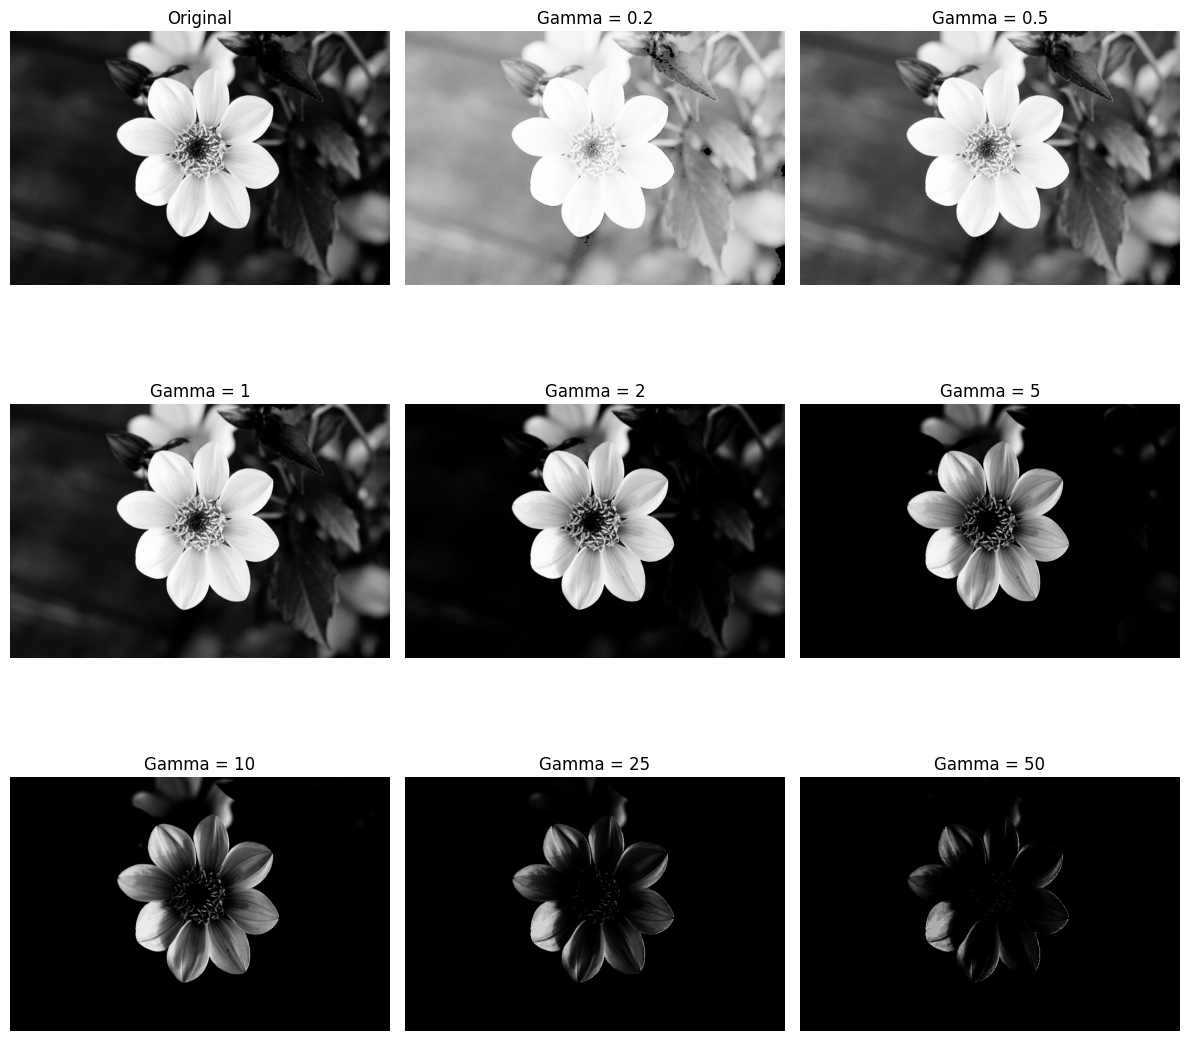

In [24]:
# Gamma values (note: duplicate 0.2 as given)
gammas = [0.2,0.5, 1, 2, 5, 10, 25, 50]

# Create figure (3x3 = 9 plots)
plt.figure(figsize=(12, 12))

# 1st image = original
plt.subplot(3, 3, 1)
plt.imshow(input, cmap='gray')
plt.title("Original")
plt.axis('off')

# Remaining = gamma corrected images
for i, g in enumerate(gammas):
    img_gamma = gamma_transform(input, g)

    plt.subplot(3, 3, i + 2)
    plt.imshow(img_gamma, cmap='gray')
    plt.title(f"Gamma = {g}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **Bit plane slicing**

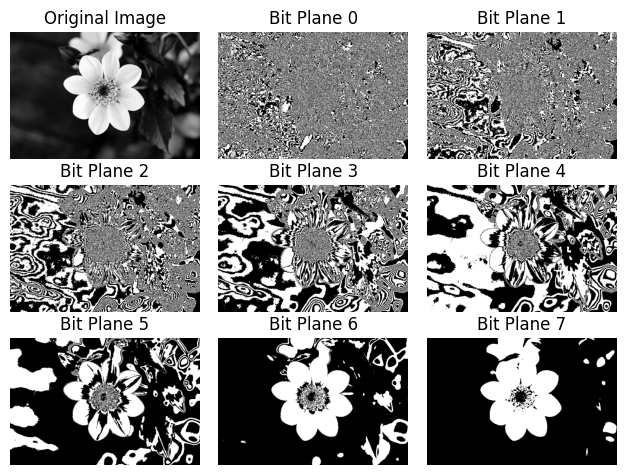

In [25]:
plt.subplot(3, 3, 1)
plt.imshow(input, cmap='gray')
plt.title("Original Image")
plt.axis('off')
for i in range(8):
    #bitwise operator shift right and bitwise and with 1.
    bit_plane = (input >> i) & 1
    #rescale values to visualize
    bit_plane = bit_plane * 255
    plt.subplot(3, 3, i + 2)
    plt.imshow(bit_plane, cmap='gray')
    plt.title(f'Bit Plane {i}')
    plt.axis('off')
plt.tight_layout()
plt.show()